# 1. Introduction

This notebook implements a **Deepfake Detection System** that classifies images as **Real** or **Fake** (AI-generated).

Multiple deep learning architectures are trained and compared:

| # | Model | Description |
|---|-------|-------------|
| 1 | **VGG16 + MTCNN** | Transfer learning with VGG16 backbone and MTCNN face extraction |
| 2 | **CNN** | Custom CNN built from scratch |
| 3 | **LSTM** | Recurrent model on reshaped image sequences |
| 4 | **CNN + LSTM** | Hybrid convolutional-recurrent architecture |
| 5 | **InceptionV3** | Transfer learning with Inception backbone |
| 6 | **InceptionV3 + Attention** | Inception backbone with custom Spatial Attention Block |

All models are evaluated using **accuracy**, **confusion matrices**, and **classification reports** to determine the best approach for deepfake detection.




# 2. Imports & Setup

All required libraries are imported here. Make sure you have them installed:

```bash
pip install tensorflow mtcnn opencv-python scikit-learn matplotlib numpy pandas seaborn
```

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from mtcnn import MTCNN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models, Model

print("All imports successful")
print(f"TensorFlow version: {tf.__version__}")

All imports successful
TensorFlow version: 2.16.2


# 3. Dataset Configuration

The dataset is organized into training and testing sets, each containing **real** and **fake** face images.
Train/Test split is predefined by the directory structure.

**Labels:** Real = 0, Fake = 1

In [3]:
BASE_PATH = "/Users/mayankpandey/Downloads/Epics/project1/archive22/dataset"

TRAIN_REAL = os.path.join(BASE_PATH, "train/real")
TRAIN_FAKE = os.path.join(BASE_PATH, "train/fake")

TEST_REAL = os.path.join(BASE_PATH, "valid/real")
TEST_FAKE = os.path.join(BASE_PATH, "valid/fake")

print(f"BASE_PATH: {BASE_PATH}")
print("Dataset structure configured.")

BASE_PATH: /Users/mayankpandey/Downloads/Epics/project1/archive22/dataset
Dataset structure configured.


# 4. Data Preprocessing

### MTCNN Face Extraction

Before feeding images to the models, we use **MTCNN (Multi-task Cascaded Convolutional Networks)** to detect and extract face regions from each image.

**Pipeline:**
1. Read image using OpenCV and convert to RGB.
2. Detect faces using MTCNN.
3. Crop the face region.
4. Resize to `224 × 224` pixels.
5. Normalize pixel values to `[0, 1]`.

In [4]:
print("Initializing MTCNN face detector...")
detector = MTCNN()
print("MTCNN detector ready")

def extract_face(img_path, size=(224,224)):
    img = cv2.imread(img_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(img_rgb)

    if len(faces) == 0:
        return None

    x, y, w, h = faces[0]['box']
    x, y = abs(x), abs(y)
    face = img_rgb[y:y+h, x:x+w]
    face = cv2.resize(face, size)

    return face

Initializing MTCNN face detector...


2026-03-26 23:38:13.767889: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-26 23:38:13.768046: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-26 23:38:13.768062: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-26 23:38:13.768086: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-26 23:38:13.768101: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


MTCNN detector ready


# 5. Data Loading

The `load_data_mtcnn()` function reads images, applies extraction, and assigns labels:
- **Real** images → label `0`
- **Fake** images → label `1`

In [5]:
def load_data_mtcnn(real_dir, fake_dir, limit=500):
    data, labels = [], []

    # REAL images → label 0
    for i, f in enumerate(os.listdir(real_dir)):
        if i >= limit:
            break
        face = extract_face(os.path.join(real_dir, f))
        if face is not None:
            data.append(face)
            labels.append(0)

    # FAKE images → label 1
    for i, f in enumerate(os.listdir(fake_dir)):
        if i >= limit:
            break
        face = extract_face(os.path.join(fake_dir, f))
        if face is not None:
            data.append(face)
            labels.append(1)

    X = np.array(data) / 255.0
    y = np.array(labels)

    return X, y

In [6]:
print("Loading dataset...")
print("Preprocessing images with MTCNN...")
X_train, y_train = load_data_mtcnn(TRAIN_REAL, TRAIN_FAKE, limit=500)
X_test, y_test = load_data_mtcnn(TEST_REAL, TEST_FAKE, limit=200)

print("\nDataset loaded successfully!")
print(f"Train shape: {X_train.shape}, Train labels: {y_train.shape}")
print(f"Test shape: {X_test.shape}, Test labels: {y_test.shape}")

Loading dataset...
Preprocessing images with MTCNN...

Dataset loaded successfully!
Train shape: (1000, 224, 224, 3), Train labels: (1000,)
Test shape: (400, 224, 224, 3), Test labels: (400,)


---
### Helper Functions
Functions for plotting training graphs and generating confusion matrices.

In [7]:
def plot_training_graphs(history, title_prefix):
    plt.figure(figsize=(12, 5))
    
    # Accuracy Graph
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f"{title_prefix} - Accuracy Graph")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    
    # Loss Graph
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f"{title_prefix} - Loss Graph")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

def evaluate_model_performance(model, X_test_data, y_test_data, title_prefix):
    print(f"Evaluating {title_prefix} model...")
    loss, acc = model.evaluate(X_test_data, y_test_data, verbose=0)
    print(f"Test Accuracy: {acc:.4f}\n")
    
    y_pred = (model.predict(X_test_data) > 0.5).astype(int)
    
    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{title_prefix} - Confusion Matrix")
    plt.show()
    
    print("\nClassification Report:\n")
    print(classification_report(y_test_data, y_pred, target_names=["Real", "Fake"]))


### Data Augmentation
Used for models that require Image Data Generators (like VGG16 and Inception).

In [8]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

---
# 1. Model Architecture: VGG16
Transfer learning using a pre-trained VGG16 model with custom dense layers for classification.

In [9]:
print("Building VGG16 Model...")
base_vgg = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

for layer in base_vgg.layers[:-4]:
    layer.trainable = False

x = base_vgg.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output_vgg = layers.Dense(1, activation='sigmoid')(x)

model_vgg = Model(inputs=base_vgg.input, outputs=output_vgg)

model_vgg.summary()

Building VGG16 Model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 7,145,217 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

# . Model Compilation
The model is compiled with the Adam optimizer (lr=1e-4) and binary crossentropy loss.

In [10]:
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# . Training Phase
Training the model for 20 epochs with a batch size of 32 utilizing data augmentation.

In [11]:
print("Training started (VGG16)...")
history_vgg = model_vgg.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=20
)
print("Training completed!")

Training started (VGG16)...
Epoch 1/20


2026-03-26 23:40:55.941048: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 607ms/step - accuracy: 0.5160 - loss: 0.7583 - val_accuracy: 0.6325 - val_loss: 0.6623
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 566ms/step - accuracy: 0.6080 - loss: 0.7033 - val_accuracy: 0.5625 - val_loss: 0.6991
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 576ms/step - accuracy: 0.6100 - loss: 0.6675 - val_accuracy: 0.6275 - val_loss: 0.6520
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 672ms/step - accuracy: 0.6700 - loss: 0.6030 - val_accuracy: 0.6125 - val_loss: 0.6581
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6550 - loss: 0.6265 - val_accuracy: 0.6600 - val_loss: 0.6118
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.7220 - loss: 0.5559 - val_accuracy: 0.7125 - val_loss: 0.5642
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.7510 - loss: 0.5227 - val_accuracy: 0.6600 - val_loss: 0.6261
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7710 - loss: 0.5081 - val_accuracy: 0.7425 - val_loss

# . Training Graphs
Visualizing training and validation metrics.

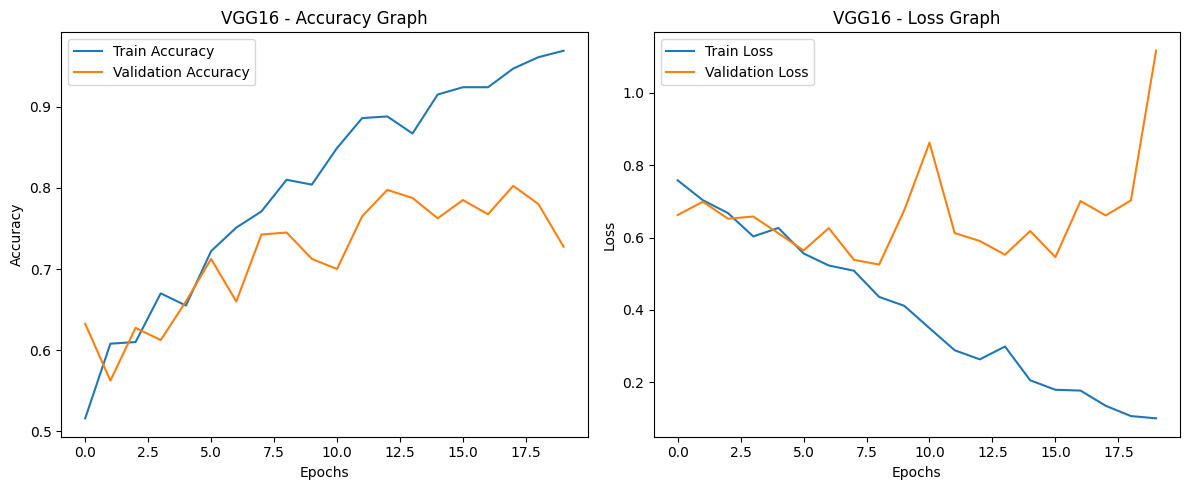

In [12]:
plot_training_graphs(history_vgg, "VGG16")

# . Evaluation and Confusion Matrix

Evaluating VGG16 model...
Test Accuracy: 0.7275

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 364ms/step


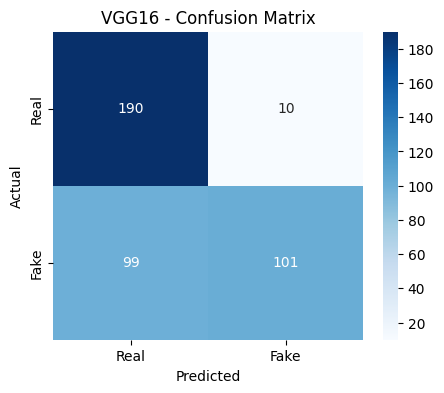


Classification Report:

              precision    recall  f1-score   support

        Real       0.66      0.95      0.78       200
        Fake       0.91      0.51      0.65       200

    accuracy                           0.73       400
   macro avg       0.78      0.73      0.71       400
weighted avg       0.78      0.73      0.71       400



In [13]:
evaluate_model_performance(model_vgg, X_test, y_test, "VGG16")

# . Model Saving

In [14]:
model_vgg.save("vgg16_mtcnn.keras")
print("Model saved to vgg16_mtcnn.keras")

Model saved to vgg16_mtcnn.keras


---
# 2. Model Architecture: Custom CNN
A custom Convolutional Neural Network built from scratch with 3 Conv blocks.

In [15]:
print("Building Custom CNN Model...")
model_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_cnn.summary()

Building Custom CNN Model...


/opt/anaconda3/envs/deepfake_gpu/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# . Model Compilation

In [16]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# . Training Phase

In [17]:
print("Training started (Custom CNN)...")
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)
print("Training completed!")

Training started (Custom CNN)...
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - accuracy: 0.4850 - loss: 0.7764 - val_accuracy: 0.5300 - val_loss: 0.6893
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.4910 - loss: 0.7233 - val_accuracy: 0.5750 - val_loss: 0.6872
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.5100 - loss: 0.7139 - val_accuracy: 0.6275 - val_loss: 0.6800
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.5570 - loss: 0.6938 - val_accuracy: 0.6000 - val_loss: 0.6710
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.5560 - loss: 0.7161 - val_accuracy: 0.6175 - val_loss: 0.6687
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.5680 - loss: 0.6924 - val_accuracy: 0.6250 - val_loss: 0.6532
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.6070 - loss: 0.6720 - val_accuracy: 0.6175 - val_loss: 0.6492
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.6220 

# . Training Graphs

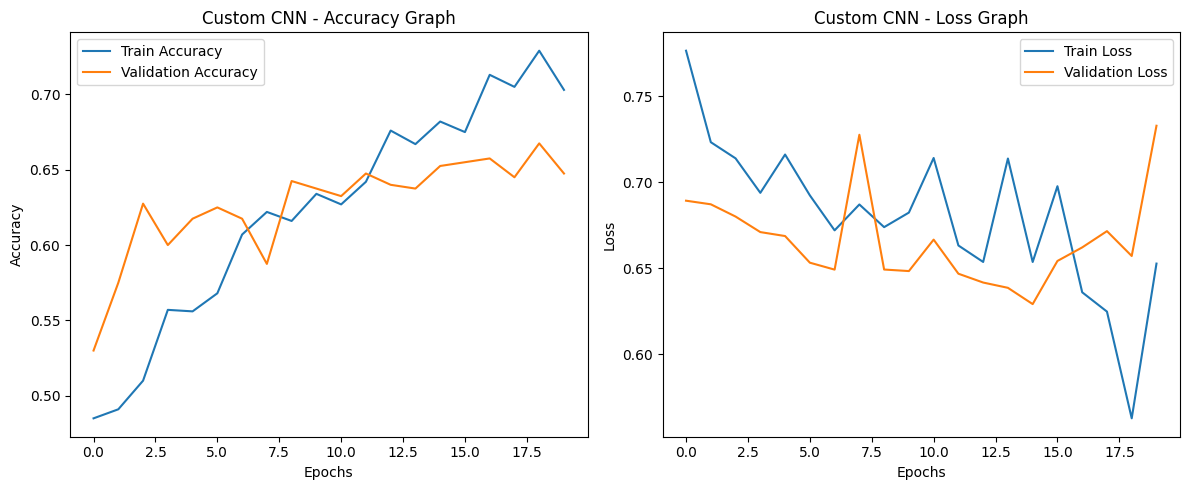

In [18]:
plot_training_graphs(history_cnn, "Custom CNN")

# . Evaluation and Confusion Matrix

Evaluating Custom CNN model...
Test Accuracy: 0.6475

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


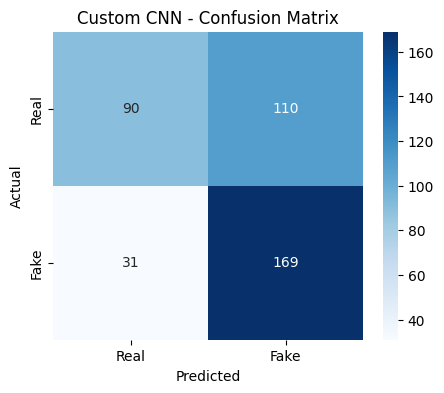


Classification Report:

              precision    recall  f1-score   support

        Real       0.74      0.45      0.56       200
        Fake       0.61      0.84      0.71       200

    accuracy                           0.65       400
   macro avg       0.67      0.65      0.63       400
weighted avg       0.67      0.65      0.63       400



In [19]:
evaluate_model_performance(model_cnn, X_test, y_test, "Custom CNN")

# . Model Saving

In [20]:
model_cnn.save("custom_cnn.keras")
print("Model saved to custom_cnn.keras")

Model saved to custom_cnn.keras


---
# 3. Model Architecture: LSTM
A recurrent neural network using LSTM layers on reshaped flat images.

In [21]:
print("Reshaping data for LSTM...")
X_train_lstm = X_train.reshape(X_train.shape[0], 224, 224*3)
X_test_lstm  = X_test.reshape(X_test.shape[0], 224, 224*3)
print(f"X_train_lstm shape: {X_train_lstm.shape}")

print("Building LSTM Model...")
model_lstm = models.Sequential([
    layers.LSTM(128, return_sequences=False, input_shape=(224, 224*3)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_lstm.summary()

Reshaping data for LSTM...
X_train_lstm shape: (1000, 224, 672)
Building LSTM Model...


/opt/anaconda3/envs/deepfake_gpu/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,433 (1.60 MB)

 Trainable params: 418,433 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

# . Model Compilation

In [22]:
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# . Training Phase

In [23]:
print("Training started (LSTM)...")
history_lstm = model_lstm.fit(
    X_train_lstm, y_train,
    validation_data=(X_test_lstm, y_test),
    epochs=20,
    batch_size=32
)
print("Training completed!")

Training started (LSTM)...
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.5200 - loss: 0.7496 - val_accuracy: 0.5025 - val_loss: 0.7030
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5090 - loss: 0.7176 - val_accuracy: 0.5025 - val_loss: 0.6991
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4910 - loss: 0.7133 - val_accuracy: 0.5450 - val_loss: 0.6871
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4840 - loss: 0.7105 - val_accuracy: 0.5250 - val_loss: 0.6882
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5170 - loss: 0.6947 - val_accuracy: 0.5375 - val_loss: 0.6876
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5260 - loss: 0.6981 - val_accuracy: 0.5050 - val_loss: 0.7042
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5290 - loss: 0.6948 - val_accuracy: 0.5075 - val_loss: 0.6994
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5330 - loss: 0.6968

# . Training Graphs

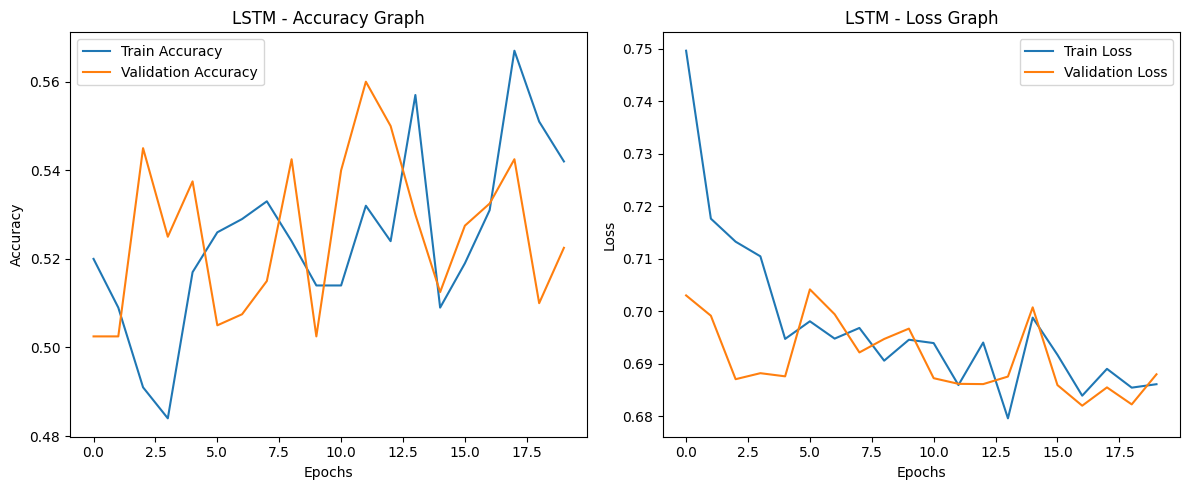

In [24]:
plot_training_graphs(history_lstm, "LSTM")

# . Evaluation and Confusion Matrix

Evaluating LSTM model...
Test Accuracy: 0.5225

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


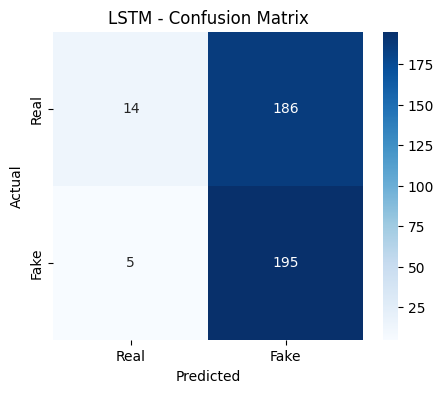


Classification Report:

              precision    recall  f1-score   support

        Real       0.74      0.07      0.13       200
        Fake       0.51      0.97      0.67       200

    accuracy                           0.52       400
   macro avg       0.62      0.52      0.40       400
weighted avg       0.62      0.52      0.40       400



In [25]:
evaluate_model_performance(model_lstm, X_test_lstm, y_test, "LSTM")

# . Model Saving

In [26]:
model_lstm.save("lstm_model.keras")
print("Model saved to lstm_model.keras")

Model saved to lstm_model.keras


---
# 4. Model Architecture: CNN + LSTM
A hybrid model utilizing convolutional layers for feature extraction and an LSTM layer for temporal patterns.

In [27]:
print("Building CNN+LSTM Model...")
inputs = tf.keras.Input(shape=(224,224,3))

x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Reshape((-1, x.shape[-1]))(x)
x = layers.LSTM(64)(x)

x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
output_cnn_lstm = layers.Dense(1, activation='sigmoid')(x)

model_cnn_lstm = Model(inputs, output_cnn_lstm)

model_cnn_lstm.summary()

Building CNN+LSTM Model...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 676, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,881 (573.75 KB)

 Trainable params: 146,881 (573.75 KB)

 Non-trainable params: 0 (0.00 B)

# . Model Compilation

In [28]:
model_cnn_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# . Training Phase

In [29]:
print("Training started (CNN + LSTM)...")
history_cnn_lstm = model_cnn_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)
print("Training completed!")

Training started (CNN + LSTM)...
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.5300 - loss: 0.6987 - val_accuracy: 0.5175 - val_loss: 0.6924
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.5170 - loss: 0.6961 - val_accuracy: 0.5275 - val_loss: 0.6920
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.5370 - loss: 0.6971 - val_accuracy: 0.5000 - val_loss: 0.6949
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.4980 - loss: 0.6996 - val_accuracy: 0.5275 - val_loss: 0.6949
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 215ms/step - accuracy: 0.4980 - loss: 0.7000 - val_accuracy: 0.5150 - val_loss: 0.6936
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - accuracy: 0.5130 - loss: 0.7041 - val_accuracy: 0.5025 - val_loss: 0.6999
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - accuracy: 0.4990 - loss: 0.7012 - val_accuracy: 0.4925 - val_loss: 0.6974
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - accuracy: 0.5130 

# . Training Graphs

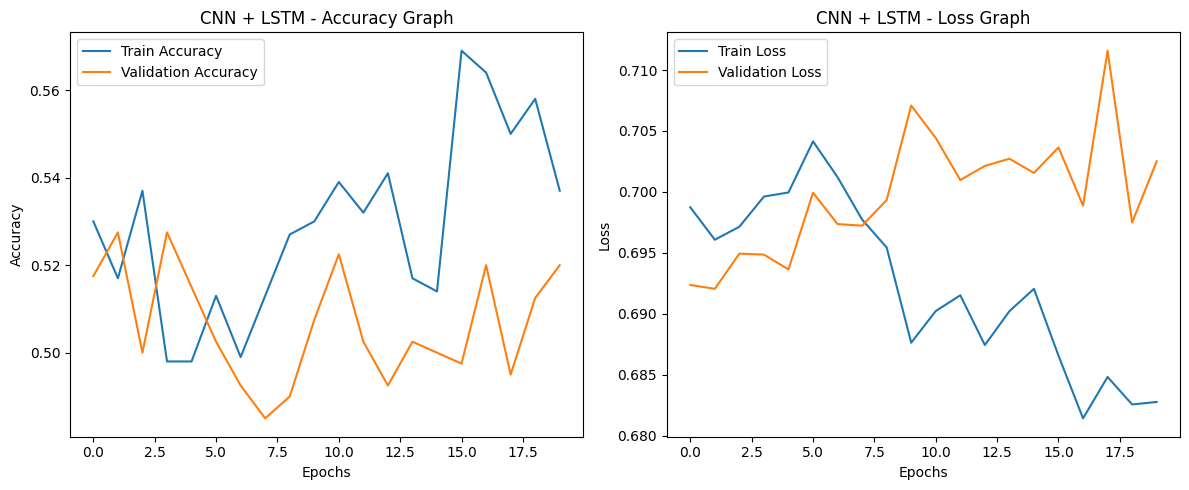

In [30]:
plot_training_graphs(history_cnn_lstm, "CNN + LSTM")

# . Evaluation and Confusion Matrix

Evaluating CNN + LSTM model...
Test Accuracy: 0.5200

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


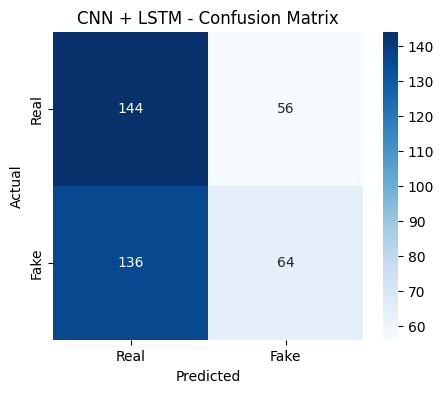


Classification Report:

              precision    recall  f1-score   support

        Real       0.51      0.72      0.60       200
        Fake       0.53      0.32      0.40       200

    accuracy                           0.52       400
   macro avg       0.52      0.52      0.50       400
weighted avg       0.52      0.52      0.50       400



In [31]:
evaluate_model_performance(model_cnn_lstm, X_test, y_test, "CNN + LSTM")

# . Model Saving

In [32]:
model_cnn_lstm.save("cnn_lstm_model.keras")
print("Model saved to cnn_lstm_model.keras")

Model saved to cnn_lstm_model.keras


---
# 5. Model Architecture: InceptionV3
Transfer learning using a pre-trained InceptionV3 backbone with the last 120 layers unfrozen.

In [33]:
print("Building InceptionV3 Model...")
base_inception_v3 = tf.keras.applications.InceptionV3(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

for layer in base_inception_v3.layers[:-120]:
    layer.trainable = False
for layer in base_inception_v3.layers[-120:]:
    layer.trainable = True

x = base_inception_v3.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
output_inception = layers.Dense(1, activation='sigmoid')(x)

model_inception = Model(base_inception_v3.input, output_inception)

model_inception.summary()

Building InceptionV3 Model...


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 111, 111,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d_6[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,327,585 (85.17 MB)

 Trainable params: 15,476,929 (59.04 MB)

 Non-trainable params: 6,850,656 (26.13 MB)

# . Model Compilation

In [34]:
model_inception.compile(
    optimizer=tf.keras.optimizers.Adam(2e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# . Training Phase

In [35]:
print("Training started (InceptionV3)...")
history_inception = model_inception.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=20
)
print("Training completed!")

Training started (InceptionV3)...
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 893ms/step - accuracy: 0.6700 - loss: 0.6744 - val_accuracy: 0.5675 - val_loss: 1.1486
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 502ms/step - accuracy: 0.8040 - loss: 0.4478 - val_accuracy: 0.5250 - val_loss: 2.4563
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 469ms/step - accuracy: 0.8730 - loss: 0.3032 - val_accuracy: 0.7675 - val_loss: 0.5287
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 508ms/step - accuracy: 0.9080 - loss: 0.2107 - val_accuracy: 0.6950 - val_loss: 1.2160
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 527ms/step - accuracy: 0.9200 - loss: 0.2191 - val_accuracy: 0.7250 - val_loss: 0.9336
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 603ms/step - accuracy: 0.9300 - loss: 0.1723 - val_accuracy: 0.7250 - val_loss: 1.3185
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 834ms/step - accuracy: 0.9610 - loss: 0.1270 - val_accuracy: 0.7875 - val_loss: 0.6569
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 710ms/step - accuracy

# . Training Graphs

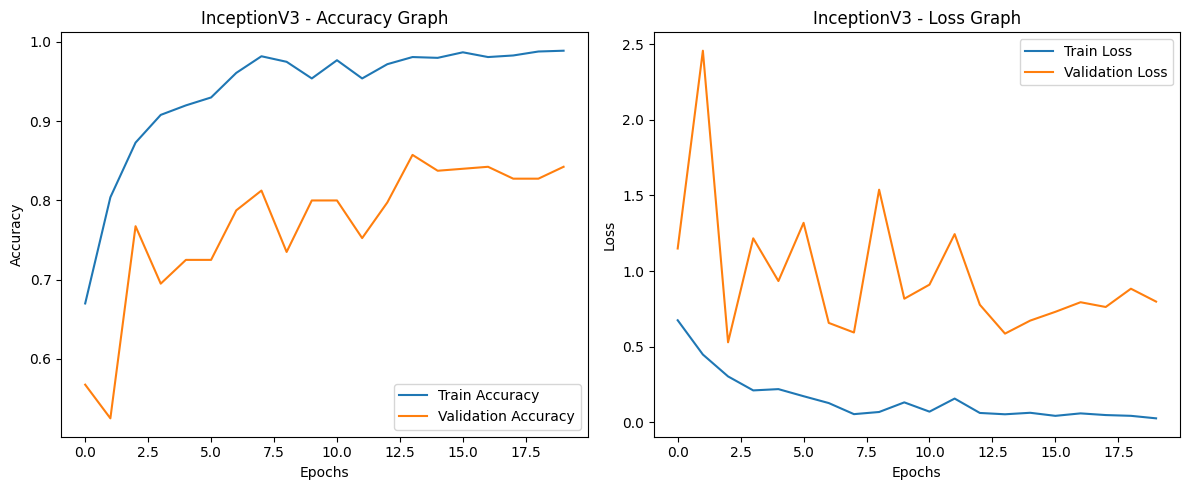

In [36]:
plot_training_graphs(history_inception, "InceptionV3")

# . Evaluation and Confusion Matrix

Evaluating InceptionV3 model...
Test Accuracy: 0.8425

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 458ms/step


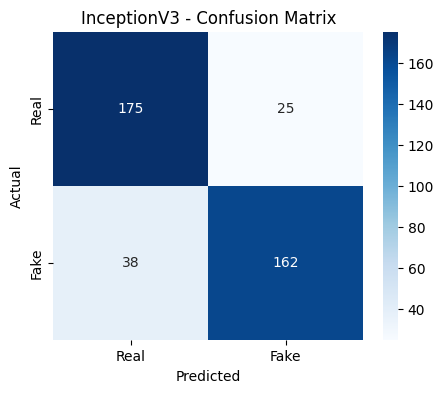


Classification Report:

              precision    recall  f1-score   support

        Real       0.82      0.88      0.85       200
        Fake       0.87      0.81      0.84       200

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



In [37]:
evaluate_model_performance(model_inception, X_test, y_test, "InceptionV3")

# . Model Saving

In [38]:
model_inception.save("inception_v3.keras")
print("Model saved to inception_v3.keras")

Model saved to inception_v3.keras


---
# 6. Model Architecture: InceptionV3 + Attention
InceptionV3 combined with a custom spatial attention block to focus on important facial features.

In [39]:
print("Defining Attention Block...")
def attention_block(x):
    gap = layers.GlobalAveragePooling2D()(x)
    dense1 = layers.Dense(64, activation='relu')(gap)
    dense2 = layers.Dense(x.shape[-1], activation='sigmoid')(dense1)
    scale = layers.Reshape((1,1,x.shape[-1]))(dense2)
    x = layers.Multiply()([x, scale])
    return x

print("Building InceptionV3 + Attention Model...")
base_att = tf.keras.applications.InceptionV3(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)
for layer in base_att.layers[:-120]:
    layer.trainable = False
for layer in base_att.layers[-120:]:
    layer.trainable = True

x = base_att.output
# CNN refinement
x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
# Attention
x = attention_block(x)
# pooling
x = layers.GlobalAveragePooling2D()(x)
# classifier
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.6)(x)
output_att = layers.Dense(1, activation='sigmoid')(x)

model_attention = Model(inputs=base_att.input, outputs=output_att)
model_attention.summary()

Defining Attention Block...
Building InceptionV3 + Attention Model...


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_100 (Conv2D) │ (None, 111, 111,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_100[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_101 (Conv2D) │ (None, 109, 109,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_101[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_102 (Conv2D) │ (None, 109, 109,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_102[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 54, 54,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 54, 54,    │      5,120 │ max_pooling2d_10… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_103[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_104 (Conv2D) │ (None, 52, 52,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_104[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 26,621,793 (101.55 MB)

 Trainable params: 19,770,625 (75.42 MB)

 Non-trainable params: 6,851,168 (26.14 MB)

# . Model Compilation

In [40]:
model_attention.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# . Training Phase


In [42]:
print("Training started (InceptionV3 + Attention)...")

history_attention = model_attention.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=20
)

print("Training completed!")

Training started (InceptionV3 + Attention)...
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 531ms/step - accuracy: 0.9400 - loss: 0.1565 - val_accuracy: 0.6875 - val_loss: 1.0128
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 504ms/step - accuracy: 0.9430 - loss: 0.1412 - val_accuracy: 0.7875 - val_loss: 0.6413
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 562ms/step - accuracy: 0.9580 - loss: 0.1158 - val_accuracy: 0.7750 - val_loss: 0.8257
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9440 - loss: 0.1242 - val_accuracy: 0.7725 - val_loss: 0.6711
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 872ms/step - accuracy: 0.9620 - loss: 0.0944 - val_accuracy: 0.7700 - val_loss: 0.6293
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 799ms/step - accuracy: 0.9670 - loss: 0.0862 - val_accuracy: 0.8025 - val_loss: 0.6140
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 592ms/step - accuracy: 0.9820 - loss: 0.0546 - val_accuracy: 0.8025 - val_loss: 0.6912
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 573ms/step -

# . Training Graphs

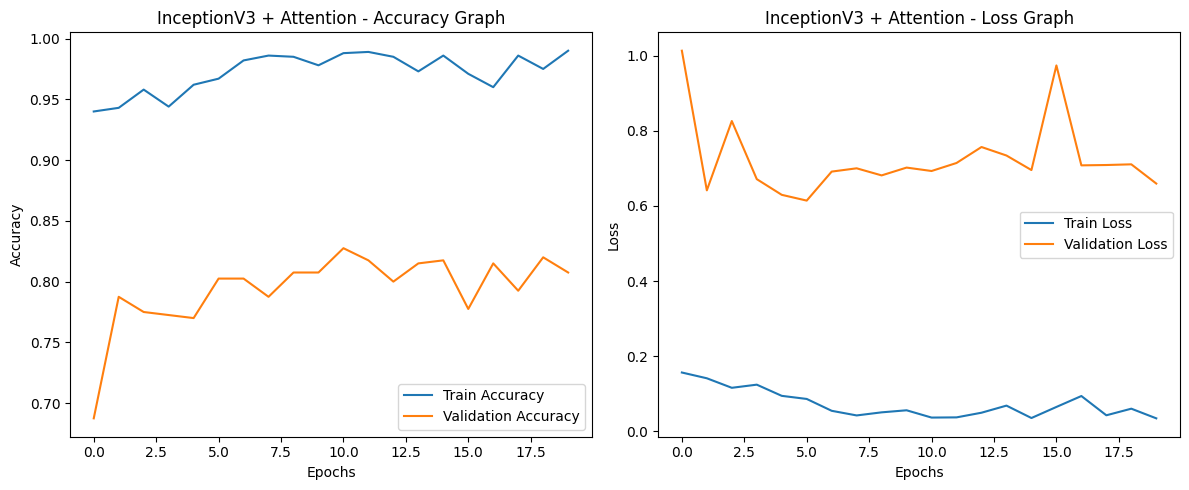

In [43]:
plot_training_graphs(history_attention, "InceptionV3 + Attention")

# . Evaluation and Confusion Matrix

Evaluating InceptionV3 + Attention model...
Test Accuracy: 0.8075

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 582ms/step


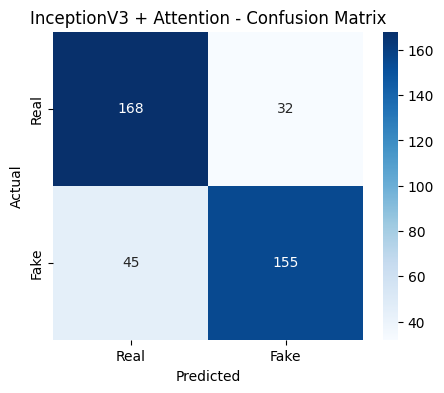


Classification Report:

              precision    recall  f1-score   support

        Real       0.79      0.84      0.81       200
        Fake       0.83      0.78      0.80       200

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



In [44]:
evaluate_model_performance(model_attention, X_test, y_test, "InceptionV3 + Attention")

# . Model Saving

In [45]:
model_attention.save("inception_attention.keras")
print("Model saved to inception_attention.keras")

Model saved to inception_attention.keras


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 355ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step


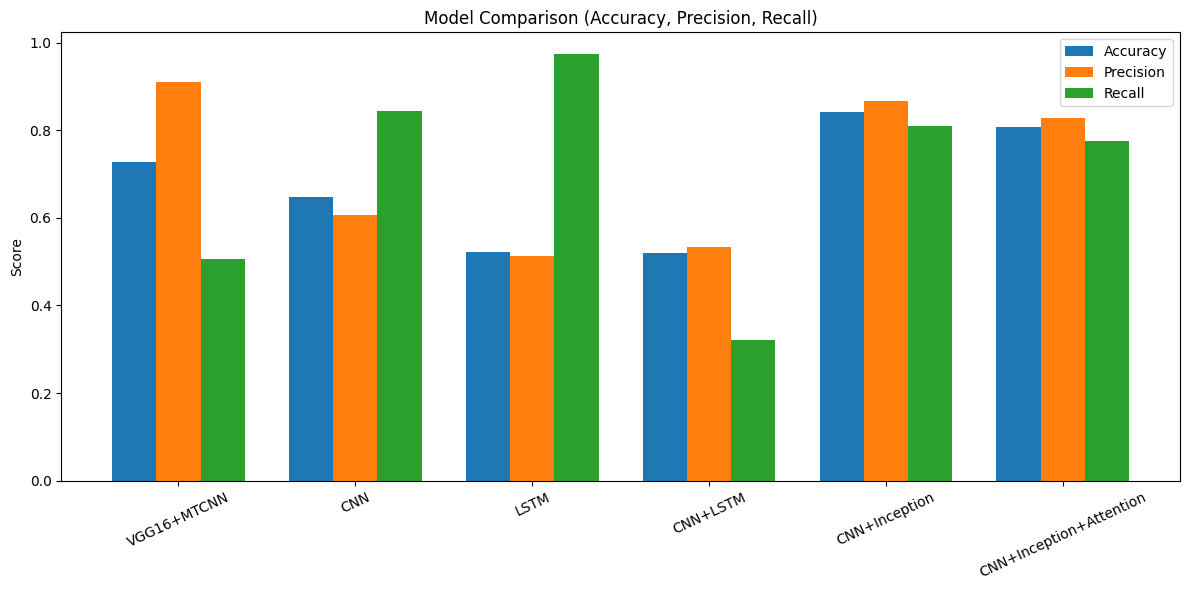

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# Predictions (already have above but keeping safe)
y_pred_vgg = (model_vgg.predict(X_test) > 0.5).astype(int).ravel()
y_pred_cnn = (model_cnn.predict(X_test) > 0.5).astype(int).ravel()
y_pred_lstm = (model_lstm.predict(X_test_lstm) > 0.5).astype(int).ravel()
y_pred_cnn_lstm = (model_cnn_lstm.predict(X_test) > 0.5).astype(int).ravel()
y_pred_inception = (model_inception.predict(X_test) > 0.5).astype(int).ravel()
y_pred_attention = (model_attention.predict(X_test) > 0.5).astype(int).ravel()
models = [
    "VGG16+MTCNN",
    "CNN",
    "LSTM",
    "CNN+LSTM",
    "CNN+Inception",
    "CNN+Inception+Attention"
]

accuracies = [
    accuracy_score(y_test, y_pred_vgg),
    accuracy_score(y_test, y_pred_cnn),
    accuracy_score(y_test, y_pred_lstm),
    accuracy_score(y_test, y_pred_cnn_lstm),
    accuracy_score(y_test, y_pred_inception),
    accuracy_score(y_test, y_pred_attention)
]

precisions = [
    precision_score(y_test, y_pred_vgg),
    precision_score(y_test, y_pred_cnn),
    precision_score(y_test, y_pred_lstm),
    precision_score(y_test, y_pred_cnn_lstm),
    precision_score(y_test, y_pred_inception),
    precision_score(y_test, y_pred_attention)
]

recalls = [
    recall_score(y_test, y_pred_vgg),
    recall_score(y_test, y_pred_cnn),
    recall_score(y_test, y_pred_lstm),
    recall_score(y_test, y_pred_cnn_lstm),
    recall_score(y_test, y_pred_inception),
    recall_score(y_test, y_pred_attention)
]

# Plot
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, accuracies, width, label='Accuracy')
plt.bar(x, precisions, width, label='Precision')
plt.bar(x + width, recalls, width, label='Recall')

plt.xticks(x, models, rotation=25)
plt.ylabel("Score")
plt.title("Model Comparison (Accuracy, Precision, Recall)")
plt.legend()

plt.tight_layout()
plt.show()

## Comparison of Model Performance Across Dataset 1 and Dataset 2

The graphs below compare the performance of six deep learning models on two different datasets:

- Dataset 1: Small dataset containing 2,041 images
  Real: 1081
  Fake: 960

- Dataset 2: Large dataset containing 10,000 images

The comparison is based on four evaluation metrics:

- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss

This analysis helps us understand how each model performs not only during training but also on unseen validation data. It also shows how model behavior changes when moving from a smaller dataset to a much larger dataset.

From the comparison, we can observe that `CNN+InceptionV3+Attention` gives the best overall performance on Dataset 1, achieving the highest training and validation accuracy with the lowest validation loss. `CNN+InceptionV3` and `VGG16+MTCNN` also perform very well, especially on the smaller dataset.

On Dataset 2, `CNN+InceptionV3` and `CNN+InceptionV3+Attention` achieve very high training accuracy, but their validation accuracy is lower than Dataset 1, suggesting some overfitting on the larger dataset. `VGG16+MTCNN` remains strong, but its validation loss increases significantly on Dataset 2.

The `CNN`, `LSTM`, and `CNN+LSTM` models show comparatively weaker performance on both datasets, with lower accuracy and higher loss values. In particular, the LSTM-based models perform poorly for this image classification task, indicating that they may not be as suitable as transfer learning approaches based on pretrained CNN backbones.

Overall, the results suggest that transfer learning models, especially those using InceptionV3 and attention mechanisms, are more effective for deepfake image classification than standard CNN or LSTM-based models.


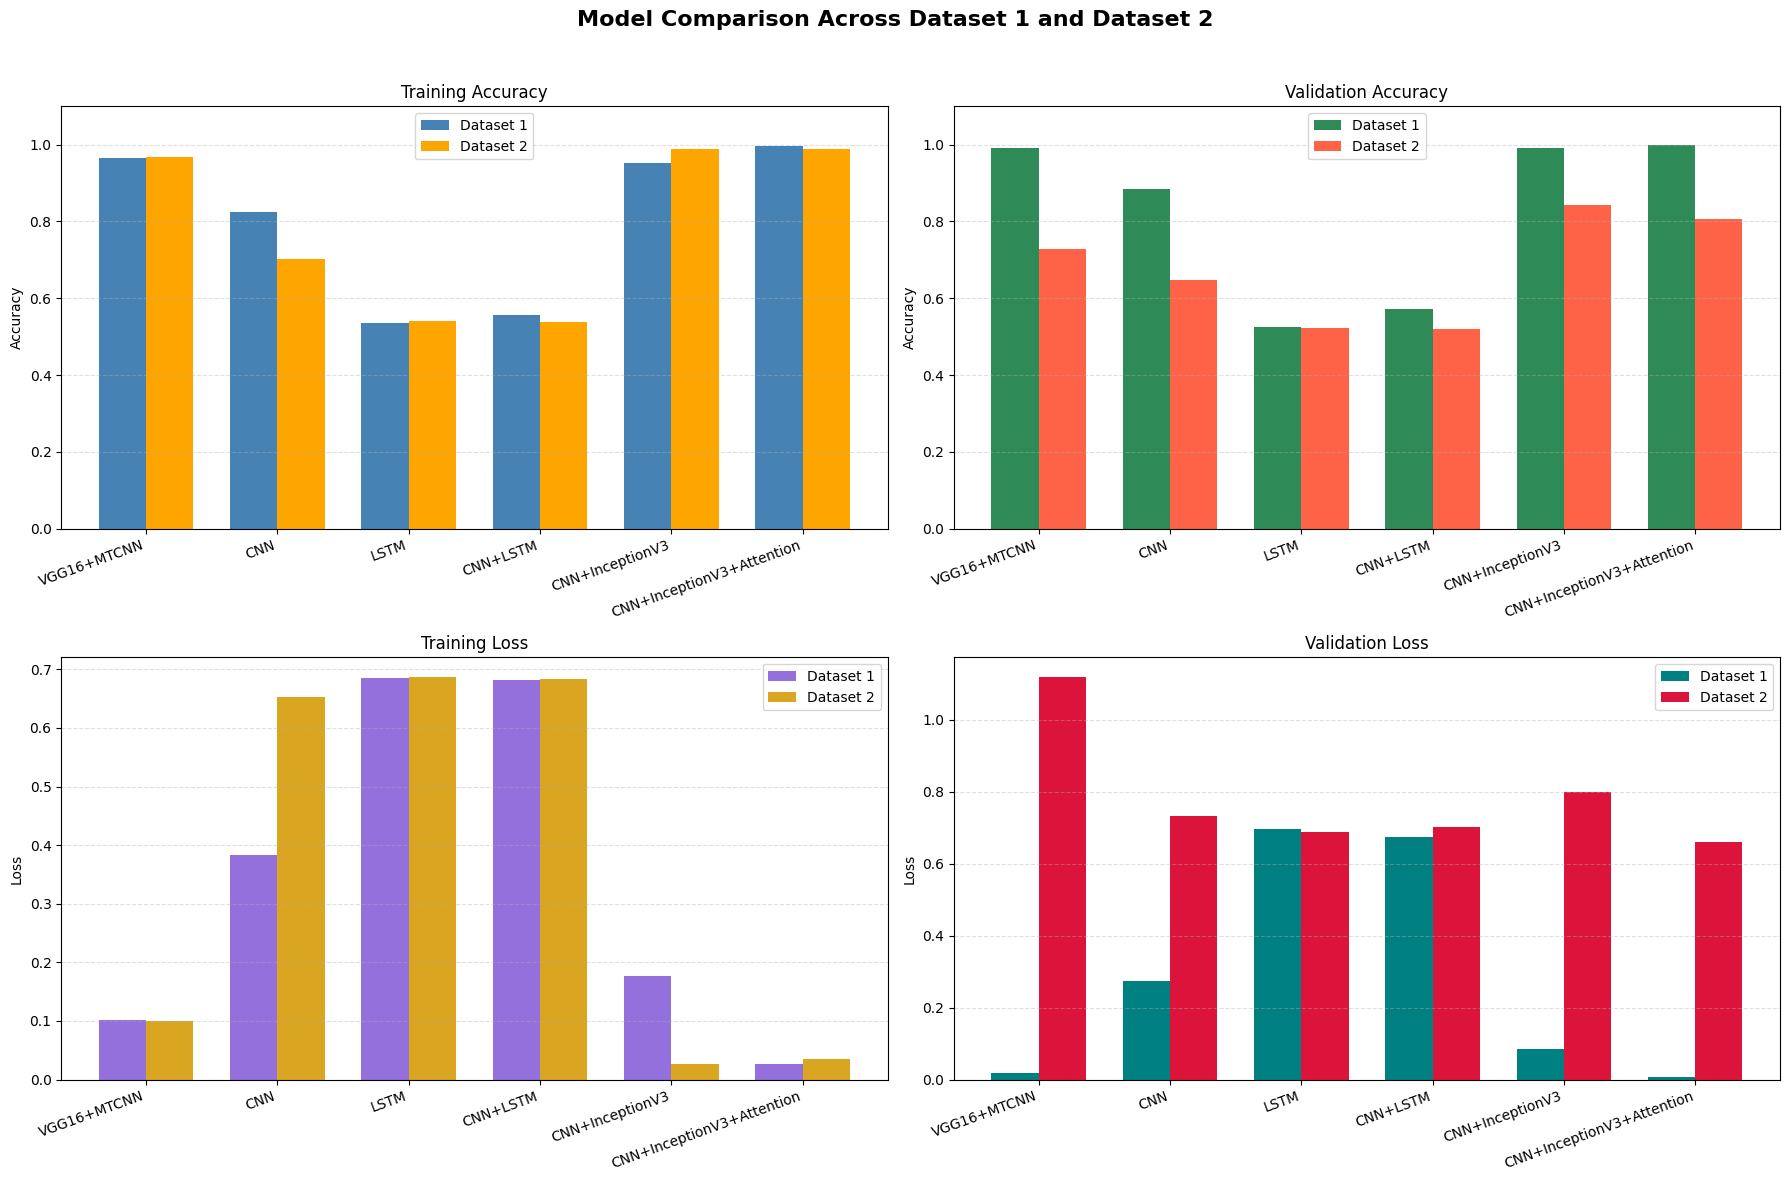

In [53]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "VGG16+MTCNN",
    "CNN",
    "LSTM",
    "CNN+LSTM",
    "CNN+InceptionV3",
    "CNN+InceptionV3+Attention"
]

# Dataset 1: small dataset
d1_accuracy = [0.9647, 0.8251, 0.5355, 0.5566, 0.9520, 0.9966]
d1_loss = [0.1023, 0.3833, 0.6858, 0.6815, 0.1759, 0.0265]
d1_val_accuracy = [0.9924, 0.8838, 0.5253, 0.5707, 0.9924, 1.0000]
d1_val_loss = [0.0174, 0.2742, 0.6971, 0.6747, 0.0856, 0.0077]

# Dataset 2: 10k images
d2_accuracy = [0.9690, 0.7030, 0.5420, 0.5370, 0.9890, 0.9900]
d2_loss = [0.0997, 0.6527, 0.6861, 0.6828, 0.0260, 0.0346]
d2_val_accuracy = [0.7275, 0.6475, 0.5225, 0.5200, 0.8425, 0.8075]
d2_val_loss = [1.1169, 0.7328, 0.6880, 0.7025, 0.7977, 0.6593]

x = np.arange(len(models))
width = 0.36

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Model Comparison Across Dataset 1 and Dataset 2", fontsize=16, fontweight="bold")

# 1. Training Accuracy
ax = axes[0, 0]
ax.bar(x - width/2, d1_accuracy, width, label="Dataset 1", color="steelblue")
ax.bar(x + width/2, d2_accuracy, width, label="Dataset 2", color="orange")
ax.set_title("Training Accuracy")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

# 2. Validation Accuracy
ax = axes[0, 1]
ax.bar(x - width/2, d1_val_accuracy, width, label="Dataset 1", color="seagreen")
ax.bar(x + width/2, d2_val_accuracy, width, label="Dataset 2", color="tomato")
ax.set_title("Validation Accuracy")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

# 3. Training Loss
ax = axes[1, 0]
ax.bar(x - width/2, d1_loss, width, label="Dataset 1", color="mediumpurple")
ax.bar(x + width/2, d2_loss, width, label="Dataset 2", color="goldenrod")
ax.set_title("Training Loss")
ax.set_ylabel("Loss")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

# 4. Validation Loss
ax = axes[1, 1]
ax.bar(x - width/2, d1_val_loss, width, label="Dataset 1", color="teal")
ax.bar(x + width/2, d2_val_loss, width, label="Dataset 2", color="crimson")
ax.set_title("Validation Loss")
ax.set_ylabel("Loss")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
